In [2]:
import torch                     # used for building deep learning models
import torch.nn as nn            # provides various neural network layers and utilities
import torch.nn.functional as F  # provides functions (without stateful parameters) like activation functions (F.relu(), F.softmax(), etc.).

In [3]:
# Create a Model Class that inherits nn.Module
class Model(nn.Module):
  # Input Layer (4 features pf the flowers) -->
  # Hideen layer1 (number of neurons) -->
  # H2 (n) -->
  # Output (3 classes of iris flower)

  def __init__(self, in_features=4, h1=8, h2=7, out_features=3):
      super().__init__() #instantiate the nn.Module (inherits from nn.Module)
      self.fc1 = nn.Linear(in_features, h1)  # fc1 = fully connected layer 1
      self.fc2 = nn.Linear(h1, h2)           # fc2 = fully connected layer 2
      self.out = nn.Linear(h2, out_features) # out = fully connected output layer


  def forward(self, x):
    # relu (rectified linear unit) = if result is 0 then output is 0,
    # else if > 0 then output is whatever the result is
    x = F.relu(self.fc1(x)) # push x in 1st layer
    x = F.relu(self.fc2(x)) # push x in 2nd layer
    x = self.out(x) # push x in output layer

    return x

In [4]:
torch.manual_seed(31) # pick a random seed for randomization

# create an instance of a model
model = Model()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
# create a url to load our dataset
url= 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
df = pd.read_csv(url)

In [7]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [8]:
df['species'].dtype

dtype('O')

In [9]:
# change last column from strings to interger
df['species'] = df['species'].replace('setosa', 0.0)
df['species'] = df['species'].replace('versicolor', 1.0)
df['species'] = df['species'].replace('virginica', 2.0)

<ipython-input-9-ddb69fdd3fde>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['species'] = df['species'].replace('virginica', 2.0)


In [10]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [11]:
# train test split
# set x, y
x = df.drop('species', axis=1)
y = df['species']

In [12]:
#
# convert to numpy arrays
x = x.values
y = y.values

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
# train test split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=31)

In [15]:
# In PyTorch, neural networks require input and target data to be in tensor format
# convert x features to float tensors
xtrain = torch.FloatTensor(xtrain)
xtest = torch.FloatTensor(xtest)

In [16]:
# convert y labels to tensors long ( 64 bit integers)
ytrain = torch.LongTensor(ytrain)
ytest = torch.LongTensor(ytest)

What is Cross-Entropy Loss?

Cross-Entropy Loss (or Softmax Loss) is used for classification problems. It measures how well a probability distribution predicted by the model matches the actual class labels.

Formula for Cross-Entropy Loss:
For a single sample with C classes, where:

𝑝
𝑖
p
i
​
  is the predicted probability of class
𝑖
i

𝑦
𝑖
y
i
​
  is the actual class label (one-hot encoded)

  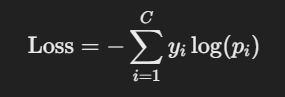

What is Adam Optimizer?

Adam (Adaptive Moment Estimation) is an advanced optimization algorithm that combines:

- Momentum (like in SGD) → Uses past gradients to accelerate learning.

- Adaptive Learning Rate (like RMSprop) → Adjusts the learning rate individually for each parameter.

In [17]:
# PyTorch's nn.CrossEntropyLoss() requires target labels to be of type torch.LongTensor, not torch.FloatTensor.
# set the criterion of model to measure the error, how far off the predicitons are from true value
criterion = nn.CrossEntropyLoss()

# choose an optimizer (Adam optimiser), lr = learning rate (if error does not go down after a bunch of iterations (epochs) we want to lower our learning rate)
# pass model parameters so optimizer can update during training
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [31]:
# model_parameters
model.eval() # fc1, fc2 and out layer

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=7, bias=True)
  (out): Linear(in_features=7, out_features=3, bias=True)
)

In [19]:
# train our model
# epochs? (one run through all the training data in our network)
# (one complete pass through the training dataset)
epochs = 100
losses = []
for i in range (epochs):
  # go forward and get a prediciton
  ypred = model.forward(xtrain) # get predicted results

  # measure the loss/error (high in beginning)
  loss = criterion(ypred, ytrain) # predicted values vs ytrain

  # Store the current loss value in a list (detaching it from the computation graph)
  # keep track of our losses
  losses.append(loss.detach().numpy()) # .detach() prevents gradients from being tracked

  # print every 10 epoch
  if i % 10 == 0:
    print(f"Epoch: {i} and loss: {loss}")

  # do backpropogation: take error rate of forward propogation
  # and feed it back through network to find tune the weights
  # Adjust the model’s weights to minimize the loss

  optimizer.zero_grad() # clear previous gradients to avoid accumulation
  loss.backward()       # Compute gradients of the loss w.r.t model parameters
  optimizer.step()      # Update model parameters using computed gradients

Epoch: 0 and loss: 1.1193890571594238
Epoch: 10 and loss: 0.9829501509666443
Epoch: 20 and loss: 0.7629573941230774
Epoch: 30 and loss: 0.5255693197250366
Epoch: 40 and loss: 0.36415597796440125
Epoch: 50 and loss: 0.2379981428384781
Epoch: 60 and loss: 0.14775125682353973
Epoch: 70 and loss: 0.09545741230249405
Epoch: 80 and loss: 0.06770675629377365
Epoch: 90 and loss: 0.05284084007143974


Text(0.5, 0, 'Epoch')

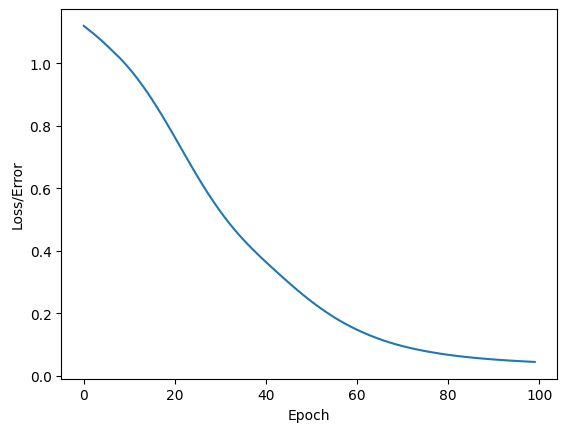

In [20]:
# graph it out:
plt.plot(range(epochs), losses)
plt.ylabel("Loss/Error")
plt.xlabel("Epoch")

In [21]:
# evaluate our model on test data set (validate on test set)

with torch.no_grad(): # turn off back propogation
  yeval = model.forward(xtest) # predictions on test set
  loss = criterion(yeval, ytest)

In [22]:
loss # performs bad on test data as it is not close to last loss at epoch 90

tensor(0.1464)

In [23]:
# check how many are correct
correct = 0

# Since we don’t need to update weights during testing
with torch.no_grad():
  for i, data in enumerate(xtest):
    yval = model.forward(data)

    # tells what type of flower it is according to our model
    # yval.argmax().item() = Finds the index of the highest value in yval (model’s predicted class).
    # .item() converts it from a PyTorch tensor to a regular Python integer.

    print(f"{i+1}) {str(yval)} \t {ytest[i]} \t {yval.argmax().item()}")

    # correct or not
    if yval.argmax().item() == ytest[i]:
      correct +=1

print(f"\ncorrect: {correct}")

1) tensor([-3.2433,  4.1403,  2.4183]) 	 1 	 1
2) tensor([-8.9777,  3.4074, 10.0046]) 	 2 	 2
3) tensor([ 11.8761,   6.6248, -17.1366]) 	 0 	 0
4) tensor([-1.4498,  4.4955,  0.0789]) 	 1 	 1
5) tensor([-7.8284,  3.8502,  8.1505]) 	 2 	 2
6) tensor([ 11.4735,   6.5575, -16.5777]) 	 0 	 0
7) tensor([-5.6668,  3.9182,  5.4758]) 	 2 	 2
8) tensor([-0.8253,  4.6467, -0.7467]) 	 1 	 1
9) tensor([ 14.4438,   8.0320, -20.8122]) 	 0 	 0
10) tensor([ 12.4097,   7.1177, -17.9495]) 	 0 	 0
11) tensor([-6.7343,  3.5744,  6.9214]) 	 2 	 2
12) tensor([-2.4381,  4.6235,  1.2379]) 	 1 	 1
13) tensor([-5.0892,  3.9848,  4.7415]) 	 2 	 2
14) tensor([ 11.9733,   6.6420, -17.1858]) 	 0 	 0
15) tensor([-9.7268,  4.1878, 10.3399]) 	 2 	 2
16) tensor([-5.8256,  3.7387,  5.7424]) 	 1 	 2
17) tensor([-4.7654,  4.0181,  4.3316]) 	 1 	 2
18) tensor([-2.9800,  4.3503,  2.0114]) 	 1 	 1
19) tensor([-8.7028,  3.1858,  9.8335]) 	 2 	 2
20) tensor([ 11.1250,   6.2696, -16.0721]) 	 0 	 0
21) tensor([-8.0819,  3.6800,  

In [24]:
# check for new/unseen data
new_iris = torch.tensor([4.6,2.3,1.7,2.5])

In [27]:
with torch.no_grad():
 new_val = model(new_iris)
 print(new_val)

 print(new_val.argmax().item())

 if new_val.argmax().item() == 0:
  print("Setosa")
 elif new_val.argmax().item() == 1:
  print("Versicolor")
 else:
  print("Virginica")

tensor([-0.5912,  3.9572, -0.7563])
1
Versicolor


In [ ]:
# the largest value within the list indicates the label it is
# in this case, 2nd value is the highest meaning it is Versicolor

In [28]:
# save our NN model

torch.save(model.state_dict(), "iris_model.pt")

In [29]:
# load the saved NN model

new_model = Model() # The model class we defined earlier
new_model.load_state_dict(torch.load("iris_model.pt"))

<All keys matched successfully>

In [30]:
# make sure it loaded correctly
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=7, bias=True)
  (out): Linear(in_features=7, out_features=3, bias=True)
)